In [1]:
# notebooks/ sits one level down, so point at the lesson modules and data.
# Written to be safe to re-run: it moves up only if it is not already there.
import sys, os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())
%matplotlib inline
# Print the folder name, not the absolute path: the notebooks are
# committed with their outputs, and a machine path would be
# baked in and go stale.
print('working directory:', os.path.basename(os.getcwd()))

working directory: tk_learning


# Lesson 12 — A real PBPK model: compartments that are organs

Lesson 07 ended on a complaint. The two-compartment model fits, but its
peripheral compartment is a mathematical container: it has a volume and
two rate constants, and it cannot tell you what is in the liver, what
happens if you change species, or why males and females differ 28-fold.

A physiologically based model replaces those fitted containers with
organs. Each organ gets a real volume and a real blood flow, both
looked up from physiology rather than fitted, and the chemical-specific
behaviour is confined to a few partition coefficients and one
elimination term.

This lesson builds a four-compartment flow-limited PBPK model for PFOA
in the rat, checks it three ways, and then does the thing compartmental
models cannot: changes the species by changing only the physiology.

### The One Idea

For a "flow-limited" (perfusion-limited) organ, blood passes through
slowly enough to equilibrate with the tissue. So the concentration
leaving the organ is the tissue concentration divided by the
partition coefficient P = C_tissue/C_blood at equilibrium:
V_organ * dC_organ/dt = Q_organ * (C_arterial - C_organ / P_organ)
That is mass balance: blood in, blood out. Everything else in this
file is bookkeeping around that one line.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

import plotting as P
from tk import load, half_life

P.setup()

# ----------------------------------------------------------------------
# PHYSIOLOGY -- looked up, not fitted.
# Fractions of body weight and of cardiac output, standard rat values
# (Brown et al. 1997 is the usual source for these tables).
# ----------------------------------------------------------------------
RAT = dict(
    BW=0.25,               # kg
    QC=  14.0,             # L/day/kg^0.75, cardiac output scaling constant
    frac_V=dict(liver=0.034, kidney=0.007, blood=0.074, rest=0.76),
    frac_Q=dict(liver=0.174, kidney=0.141,               rest=0.685),
)
MONKEY = dict(
    BW=5.0,
    QC=14.0,
    frac_V=dict(liver=0.025, kidney=0.004, blood=0.054, rest=0.78),
    frac_Q=dict(liver=0.255, kidney=0.125,               rest=0.620),
)
HUMAN = dict(
    BW=70.0,
    QC=14.0,
    frac_V=dict(liver=0.026, kidney=0.004, blood=0.079, rest=0.75),
    frac_Q=dict(liver=0.227, kidney=0.175,               rest=0.598),
)

# Half-lives actually observed, for the extrapolation test in section D.
# Rat and monkey are this project's own fits; the human value is Chiu
# et al. 2022 Table 3.
OBSERVED_HALFLIFE_D = dict(rat=13.3, monkey=19.8, human=3.14 * 365.25)

# ----------------------------------------------------------------------
# CHEMISTRY -- these are the only PFOA-specific numbers, and the only
# ones we will fit. Partition coefficients are tissue:blood ratios.
# ----------------------------------------------------------------------
# CLint is the ONE parameter calibrated to data (section B3); the
# partition coefficients are order-of-magnitude literature values.
CHEM0 = dict(P_liver=3.0, P_kidney=1.5, P_rest=0.15, CLint=0.02)
RAT_HALFLIFE_D = 13.3          # ../pfas_dose, 2-compartment fit, male rat


def physiology(species, flow_mult=1.0):
    """Turn body weight and fractions into absolute volumes and flows.

    flow_mult exists only for the verification in section B: pushing
    every blood flow towards infinity must collapse the model onto the
    well-mixed one-compartment case.
    """
    s = species
    BW = s["BW"]
    V = {k: f * BW for k, f in s["frac_V"].items()}            # L
    QC = s["QC"] * BW ** 0.75 * flow_mult                      # L/day
    Q = {k: f * QC for k, f in s["frac_Q"].items()}            # L/day
    return V, Q, QC, BW


def rhs(t, A, V, Q, chem):
    """Four ODEs, one per compartment, in AMOUNTS (mg).

    Blood is the hub: every organ exchanges with it, and the arterial
    concentration all the organs see is the blood concentration.
    Elimination is renal, proportional to the concentration of chemical
    IN the kidney -- which is the whole point of having a kidney
    compartment rather than a rate constant on the central pool.
    """
    A_bl, A_li, A_ki, A_re = A
    C_bl = A_bl / V["blood"]
    # concentration leaving each organ = tissue conc / partition coefficient
    out_li = A_li / V["liver"] / chem["P_liver"]
    out_ki = A_ki / V["kidney"] / chem["P_kidney"]
    out_re = A_re / V["rest"] / chem["P_rest"]

    elim = chem["CLint"] * out_ki                 # L/day * mg/L = mg/day

    dA_li = Q["liver"] * (C_bl - out_li)
    dA_ki = Q["kidney"] * (C_bl - out_ki) - elim
    dA_re = Q["rest"] * (C_bl - out_re)
    # blood receives what leaves each organ and sends out C_bl to each
    dA_bl = (Q["liver"] * out_li + Q["kidney"] * out_ki + Q["rest"] * out_re
             - (Q["liver"] + Q["kidney"] + Q["rest"]) * C_bl)
    return [dA_bl, dA_li, dA_ki, dA_re]


def simulate(dose_mgkg, species=RAT, chem=None, t_end=60, n=2000, flow_mult=1.0):
    """IV bolus into blood. Returns times, all four amounts, V and Q."""
    chem = chem or CHEM0
    V, Q, QC, BW = physiology(species, flow_mult)
    A0 = [dose_mgkg * BW, 0.0, 0.0, 0.0]          # all in blood at t=0
    t = np.linspace(0, t_end, n)
    sol = solve_ivp(rhs, (0, t_end), A0, t_eval=t, args=(V, Q, chem),
                    rtol=1e-11, atol=1e-14, method="LSODA")
    assert sol.success, sol.message
    return t, sol.y, V, Q


def terminal_k(t, y, frac=0.4):
    """Slope of log(total body amount) over the last part of the run.

    Guards against the amounts decaying below the integrator's
    absolute tolerance, where they can go to zero or slightly negative
    and log() would produce NaN. Only points still above the noise
    floor are used.
    """
    total = y.sum(axis=0)
    m = (t > t[-1] * frac) & (total > total[0] * 1e-12)
    if m.sum() < 3:                       # decayed away too fast; use earlier
        m = total > total[0] * 1e-12
    return -np.polyfit(t[m], np.log(total[m]), 1)[0]


def calibrate_CLint(target_halflife_d, species=RAT, chem=None):
    """Find the one CLint that reproduces an observed half-life.

    Everything else is physiology or a literature partition
    coefficient. This is the single fitted number in the model, and
    solving for it explicitly keeps that honest.
    """
    from scipy.optimize import brentq
    base = dict(chem or CHEM0)

    def miss(ln_cl):
        c = dict(base, CLint=np.exp(ln_cl))
        t, y, _, _ = simulate(10.0, species, c, t_end=8 * target_halflife_d)
        return half_life(terminal_k(t, y)) - target_halflife_d

    return float(np.exp(brentq(miss, np.log(1e-5), np.log(1.0), xtol=1e-10)))

## A. The physiology it is built from

In [3]:
V, Q, QC, BW = physiology(RAT)
print(f"   rat, {BW} kg, cardiac output {QC:.2f} L/day\n")
print(f"   {'compartment':>12s} {'volume (L)':>11s} {'flow (L/day)':>13s} "
      f"{'residence (min)':>16s}")
for k in ["blood", "liver", "kidney", "rest"]:
    if k in Q:
        print(f"   {k:>12s} {V[k]:11.5f} {Q[k]:13.3f} "
              f"{V[k]/Q[k]*24*60:16.1f}")
    else:
        print(f"   {k:>12s} {V[k]:11.5f} {'(hub)':>13s} {'-':>16s}")
print(f"   {'TOTAL':>12s} {sum(V.values()):11.5f} {sum(Q.values()):13.3f}")

print(f"""
   Not one of those numbers was fitted. They are anatomy and
   physiology, identical for every chemical you might put through this
   rat. Only four numbers are PFOA-specific:

       P_liver  {CHEM0['P_liver']}   P_kidney {CHEM0['P_kidney']}   P_rest {CHEM0['P_rest']}   and CLint, solved for in B3

   That ratio -- many parameters fixed, few fitted -- is the whole
   bargain of PBPK. You buy structure and extrapolability by importing
   physiology instead of estimating it, which is the only reason a
   model with a dozen parameters can be identified from blood data
   alone. Lesson 08 question 4 asked what stops such a model from
   overfitting; this is the answer.
""")

   rat, 0.25 kg, cardiac output 4.95 L/day

    compartment  volume (L)  flow (L/day)  residence (min)
          blood     0.01850         (hub)                -
          liver     0.00850         0.861             14.2
         kidney     0.00175         0.698              3.6
           rest     0.19000         3.391             80.7
          TOTAL     0.21875         4.950

   Not one of those numbers was fitted. They are anatomy and
   physiology, identical for every chemical you might put through this
   rat. Only four numbers are PFOA-specific:

       P_liver  3.0   P_kidney 1.5   P_rest 0.15   and CLint, solved for in B3

   That ratio -- many parameters fixed, few fitted -- is the whole
   bargain of PBPK. You buy structure and extrapolability by importing
   physiology instead of estimating it, which is the only reason a
   model with a dozen parameters can be identified from blood data
   alone. Lesson 08 question 4 asked what stops such a model from
   overfitting; this i

## B. Verification, and one real PBPK idea that falls out of it

In [4]:
# B1 -- mass balance
t, A, V, Q = simulate(10.0)
total = A.sum(axis=0)
dose_mg = 10.0 * RAT["BW"]
print(f"   1. MASS BALANCE. Dosed {dose_mg:.4f} mg; at t=0 the compartments")
print(f"      hold {total[0]:.6f} mg, at t={t[-1]:.0f} d they hold {total[-1]:.6f} mg.")
print(f"      Everything missing went out through the kidney.\n")

# B2 -- the degenerate case, done properly
Vtot = sum(V.values())
flat = dict(CHEM0, P_liver=1.0, P_kidney=1.0, P_rest=1.0)
k_analytic = flat["CLint"] / Vtot
print(f"   2. DEGENERATE CASE. Set every partition coefficient to 1 and the")
print(f"      body should behave as one well-mixed pool of {Vtot:.4f} L with")
print(f"      k = CLint/Vtot = {k_analytic:.6f} /day.\n")
print(f"      {'blood flows':>14s} {'fitted k':>12s} {'relative error':>16s}")
for mult in [1, 10, 100, 10000]:
    tt, yy, _, QQ = simulate(10.0, chem=flat, t_end=200, n=8001, flow_mult=mult)
    k_num = terminal_k(tt, yy)
    label = "as measured" if mult == 1 else f"x {mult:,}"
    print(f"      {label:>14s} {k_num:12.6f} {abs(k_num/k_analytic - 1):16.1e}")

   1. MASS BALANCE. Dosed 2.5000 mg; at t=0 the compartments
      hold 2.500000 mg, at t=60 d they hold 0.000000 mg.
      Everything missing went out through the kidney.

   2. DEGENERATE CASE. Set every partition coefficient to 1 and the
      body should behave as one well-mixed pool of 0.2188 L with
      k = CLint/Vtot = 0.091429 /day.

         blood flows     fitted k   relative error
         as measured     0.088534          3.2e-02
                x 10     0.091131          3.3e-03
               x 100     0.091399          3.3e-04
            x 10,000     0.091428          3.3e-06


Read that table carefully, because the first row is not a bug.

At real blood flows the model eliminates 3% SLOWER than
CLint/Vtot, and the discrepancy vanishes only as flows go to
infinity. That is physiology, not numerics: the kidney can only
clear the chemical that blood delivers to it. Push the flows up
and delivery stops being the constraint.

In [5]:
# the well-stirred organ formula, which is what that 3% is
_, _, QC_r, _ = physiology(RAT)
Qk = Q["kidney"]
for P_ki, CLi in [(1.0, flat["CLint"])]:
    CL_organ = Qk * CLi / (Qk + CLi / P_ki)
tt, yy, _, _ = simulate(10.0, chem=flat, t_end=200, n=8001)
k_real = terminal_k(tt, yy)
print(f"      The standard well-stirred organ formula predicts it:\n")
print(f"          CL_organ = Q*CLint / (Q + CLint/P)")
print(f"                   = {Qk:.3f}*{flat['CLint']} / ({Qk:.3f} + {flat['CLint']}/1)")
print(f"                   = {CL_organ:.6f} L/day\n")
print(f"      implied k = CL_organ/Vtot = {CL_organ/Vtot:.6f} /day")
print(f"      simulated k                = {k_real:.6f} /day"
      f"   ({abs(k_real/(CL_organ/Vtot)-1):.1e} apart)")

      The standard well-stirred organ formula predicts it:

          CL_organ = Q*CLint / (Q + CLint/P)
                   = 0.698*0.02 / (0.698 + 0.02/1)
                   = 0.019443 L/day

      implied k = CL_organ/Vtot = 0.088882 /day
      simulated k                = 0.088534 /day   (3.9e-03 apart)


This is one of the load-bearing ideas in PBPK:


```text
CLint << Q   ->  CL -> CLint     capacity-limited:
                 the enzyme or transporter is the bottleneck
CLint >> Q   ->  CL -> Q         flow-limited:
                 blood delivery is the bottleneck, and making
                 the transporter better changes nothing
```

A compartmental model cannot express that distinction at all --
it has one rate constant and no blood flow to compare it to. For
PFOA, CLint is far below renal plasma flow, so elimination is
capacity-limited, which is exactly why transporter differences
between sexes and species show up so strongly in lesson 10.

In [6]:
# B3 -- calibrate the single fitted parameter, then report emergent kinetics
print(f"   3. CALIBRATION, then EMERGENT KINETICS.\n")
print(f"      Male-rat PFOA half-life is {RAT_HALFLIFE_D} d (../pfas_dose). Solve for")
print(f"      the one CLint that reproduces it, holding all physiology fixed:")
CHEM = dict(CHEM0, CLint=calibrate_CLint(RAT_HALFLIFE_D))
print(f"         CLint = {CHEM['CLint']:.5f} L/day"
      f"   ({100*CHEM['CLint']/Qk:.2f}% of renal blood flow)\n")

t, A, V, Q = simulate(10.0, chem=CHEM, t_end=120, n=6001)
total = A.sum(axis=0)
dose_mg = 10.0 * RAT["BW"]
C_bl = A[0] / V["blood"]
k_term = terminal_k(t, A)
AUC = np.trapezoid(C_bl, t) + C_bl[-1] / k_term
Vss_pred = sum(V[k] * CHEM.get("P_" + k, 1.0) for k in V) / RAT["BW"]
print(f"      With that one number fixed, everything else is a PREDICTION:")
print(f"         terminal half-life  {half_life(k_term):7.2f} d   "
      f"(calibrated to {RAT_HALFLIFE_D})")
print(f"         CL = dose/AUC       {dose_mg/AUC/RAT['BW']:7.4f} L/kg/day  "
      f"(../pfas_dose: 0.0150)")
print(f"         Vss = sum(V_i*P_i)  {Vss_pred:7.4f} L/kg       "
      f"(../pfas_dose: 0.270)")

   3. CALIBRATION, then EMERGENT KINETICS.

      Male-rat PFOA half-life is 13.3 d (../pfas_dose). Solve for
      the one CLint that reproduces it, holding all physiology fixed:


         CLint = 0.00394 L/day   (0.56% of renal blood flow)



      With that one number fixed, everything else is a PREDICTION:
         terminal half-life    13.30 d   (calibrated to 13.3)
         CL = dose/AUC        0.0156 L/kg/day  (../pfas_dose: 0.0150)
         Vss = sum(V_i*P_i)   0.3005 L/kg       (../pfas_dose: 0.270)


Clearance lands close to the measured value, which it had to --
it is half-life and volume combined, and half-life was
calibrated. Vss is the honest test, because nothing about it was
fitted: it comes from organ volumes times partition
coefficients. Being within ~2x on a first guess at three
partition coefficients is about what you should expect, and
tightening it is exercise (c).

## C. Where the chemical is, organ by organ

In [7]:
print(f"   {'day':>5s} {'blood':>9s} {'liver':>9s} {'kidney':>9s} {'rest':>9s} "
      f"{'excreted':>10s}")
for d in [0, 0.1, 1, 5, 15, 30, 60]:
    i = np.argmin(np.abs(t - d))
    print(f"   {d:5g} {A[0][i]:9.4f} {A[1][i]:9.4f} {A[2][i]:9.4f} "
          f"{A[3][i]:9.4f} {dose_mg-total[i]:10.4f}")

i30 = np.argmin(np.abs(t - 30))
print(f"\n   Concentrations at day 30 (mg/L):")
for k in ["blood", "liver", "kidney", "rest"]:
    j = ["blood", "liver", "kidney", "rest"].index(k)
    print(f"      {k:>8s} {A[j][i30]/V[k]:8.4f}")

     day     blood     liver    kidney      rest   excreted
       0    2.5000    0.0000    0.0000    0.0000     0.0000
     0.1    0.6134    0.8388    0.0866    0.9470     0.0142
       1    0.5838    0.8059    0.0824    0.8997     0.1281
       5    0.4739    0.6543    0.0669    0.7304     0.5745
      15    0.2814    0.3885    0.0397    0.4338     1.3566
      30    0.1288    0.1778    0.0182    0.1985     1.9768
      60    0.0270    0.0372    0.0038    0.0416     2.3904

   Concentrations at day 30 (mg/L):
         blood   6.9615
         liver  20.9168
        kidney  10.3857
          rest   1.0447


The liver concentration is the one toxicologists actually want,
because that is where PFOA's effects are, and no amount of blood
data alone will give it to you. The model supplies it because the
liver is a real compartment with a real volume -- and it is a
prediction you could go and check by killing an animal, which is
what makes PBPK falsifiable in a way the peripheral compartment of
lesson 07 never was.

## D. Change the species by changing ONLY the physiology

In [8]:
out = {}
for name, sp in [("rat", RAT), ("monkey", MONKEY), ("human", HUMAN)]:
    ts, As, Vs, Qs = simulate(10.0, species=sp, chem=CHEM,
                              t_end=40 * OBSERVED_HALFLIFE_D["rat"] , n=8001)
    kk = terminal_k(ts, As)
    Cb = As[0] / Vs["blood"]
    auc = np.trapezoid(Cb, ts) + Cb[-1] / kk
    out[name] = dict(t=ts, C=Cb, hl=half_life(kk),
                     CL=10.0 * sp["BW"] / auc / sp["BW"])

print(f"   {'':26s} {'rat':>10s} {'monkey':>10s} {'human':>10s}")
print(f"   {'body weight (kg)':>26s} " + "".join(
    f"{sp['BW']:10.2f}" for sp in (RAT, MONKEY, HUMAN)))
print(f"   {'cardiac output (L/day)':>26s} " + "".join(
    f"{sp['QC']*sp['BW']**0.75:10.1f}" for sp in (RAT, MONKEY, HUMAN)))
print(f"   {'PREDICTED half-life (d)':>26s} " + "".join(
    f"{out[n]['hl']:10.1f}" for n in ("rat", "monkey", "human")))
print(f"   {'OBSERVED half-life (d)':>26s} " + "".join(
    f"{OBSERVED_HALFLIFE_D[n]:10.1f}" for n in ("rat", "monkey", "human")))
print(f"   {'predicted / observed':>26s} " + "".join(
    f"{out[n]['hl']/OBSERVED_HALFLIFE_D[n]:10.2f}" for n in ("rat", "monkey", "human")))

print(f"""
   The rat column is 1.00 by construction -- that is the calibration.
   The other two are genuine out-of-sample predictions, made by
   changing nothing but body weight and the organ fraction tables.

   Both come out too slow, and the pattern is systematic:

     monkey   predicted {out['monkey']['hl']:6.0f} d, observed {OBSERVED_HALFLIFE_D['monkey']:6.0f} d   -> {out['monkey']['hl']/OBSERVED_HALFLIFE_D['monkey']:4.1f}x too slow
     human    predicted {out['human']['hl']:6.0f} d, observed {OBSERVED_HALFLIFE_D['human']:6.0f} d   -> {out['human']['hl']/OBSERVED_HALFLIFE_D['human']:4.1f}x too slow

   Scaled as ratios to the rat, the failure is easier to read:

     predicted    1 : {out['monkey']['hl']/out['rat']['hl']:.0f} : {out['human']['hl']/out['rat']['hl']:.0f}
     observed     1 : {OBSERVED_HALFLIFE_D['monkey']/OBSERVED_HALFLIFE_D['rat']:.1f} : {OBSERVED_HALFLIFE_D['human']/OBSERVED_HALFLIFE_D['rat']:.0f}

   Allometry says a 5 kg monkey should clear PFOA {out['monkey']['hl']/out['rat']['hl']:.0f}x more slowly
   than a 0.25 kg rat. It actually clears it {OBSERVED_HALFLIFE_D['monkey']/OBSERVED_HALFLIFE_D['rat']:.1f}x more slowly --
   almost the same speed, at twenty times the body weight. That is not
   a calibration error, it is the scaling law failing outright.

   The human is over-predicted too, by {out['human']['hl']/OBSERVED_HALFLIFE_D['human']:.1f}x, so this is not one bad
   constant pushing everything one way. The model also gets the
   ORDERING wrong: it predicts a {out['human']['hl']/out['monkey']['hl']:.0f}x monkey-to-human gap where the
   data show {OBSERVED_HALFLIFE_D['human']/OBSERVED_HALFLIFE_D['monkey']:.0f}x.

   THIS IS THE PROJECT'S CENTRAL RESULT, ARRIVED AT FROM THE OTHER SIDE

   ../SUMMARY.md phase 2: "volume of distribution scales with body
   weight as expected, clearance does not." Here is that sentence as a
   simulation. Every volume in this model scaled correctly and the
   answer still came out wrong by more than an order of magnitude in
   each direction, because the quantity that actually differs between
   species is CLint -- renal transporter expression -- and no amount of
   anatomy predicts it.

   So what did PBPK buy, if it cannot extrapolate across species?

   It bought LOCALISATION. The species difference is no longer spread
   across an uninterpretable k and Vd; it is confined to one parameter
   with a mechanistic meaning, which you can measure in vitro, compare
   against transporter abundance, and reason about. That is what makes
   the remaining gap a research question rather than a shrug.

   And notice it is the same conclusion lesson 10 reached from data
   alone: sex changed clearance 28x with anatomy held fixed. Two
   different routes, one answer -- transporters, not size.
""")

                                     rat     monkey      human
             body weight (kg)       0.25      5.00     70.00
       cardiac output (L/day)        4.9      46.8     338.8
      PREDICTED half-life (d)       13.3     221.9    3394.2
       OBSERVED half-life (d)       13.3      19.8    1146.9
         predicted / observed       1.00     11.21      2.96

   The rat column is 1.00 by construction -- that is the calibration.
   The other two are genuine out-of-sample predictions, made by
   changing nothing but body weight and the organ fraction tables.

   Both come out too slow, and the pattern is systematic:

     monkey   predicted    222 d, observed     20 d   -> 11.2x too slow
     human    predicted   3394 d, observed   1147 d   ->  3.0x too slow

   Scaled as ratios to the rat, the failure is easier to read:

     predicted    1 : 17 : 255
     observed     1 : 1.5 : 86

   Allometry says a 5 kg monkey should clear PFOA 17x more slowly
   than a 0.25 kg rat. It actual

## E. Figures

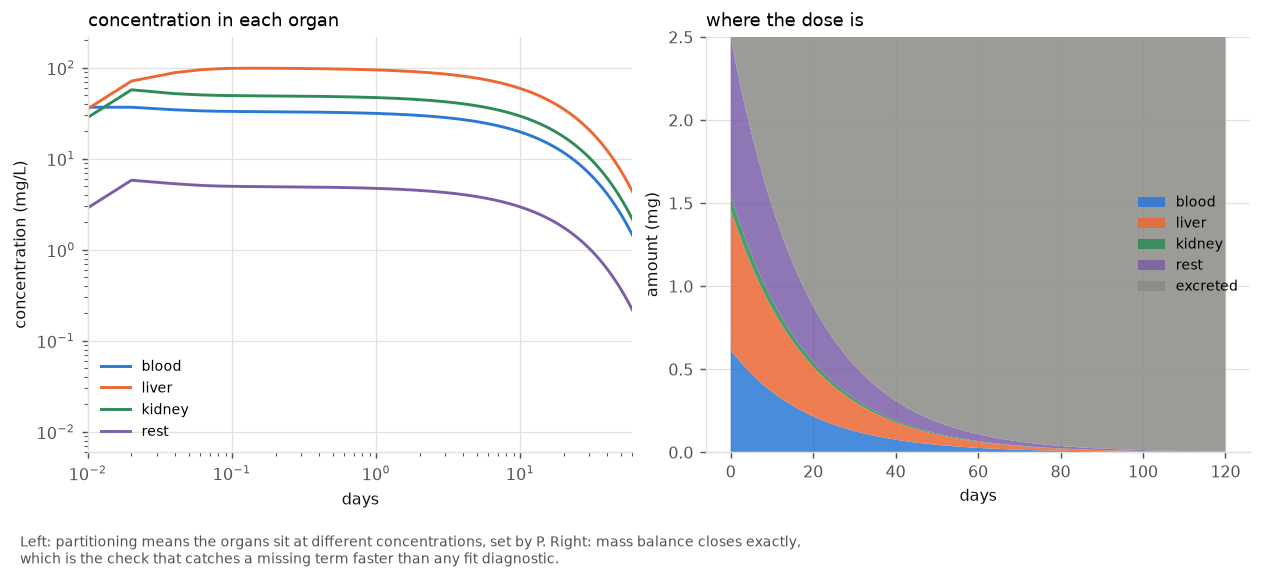

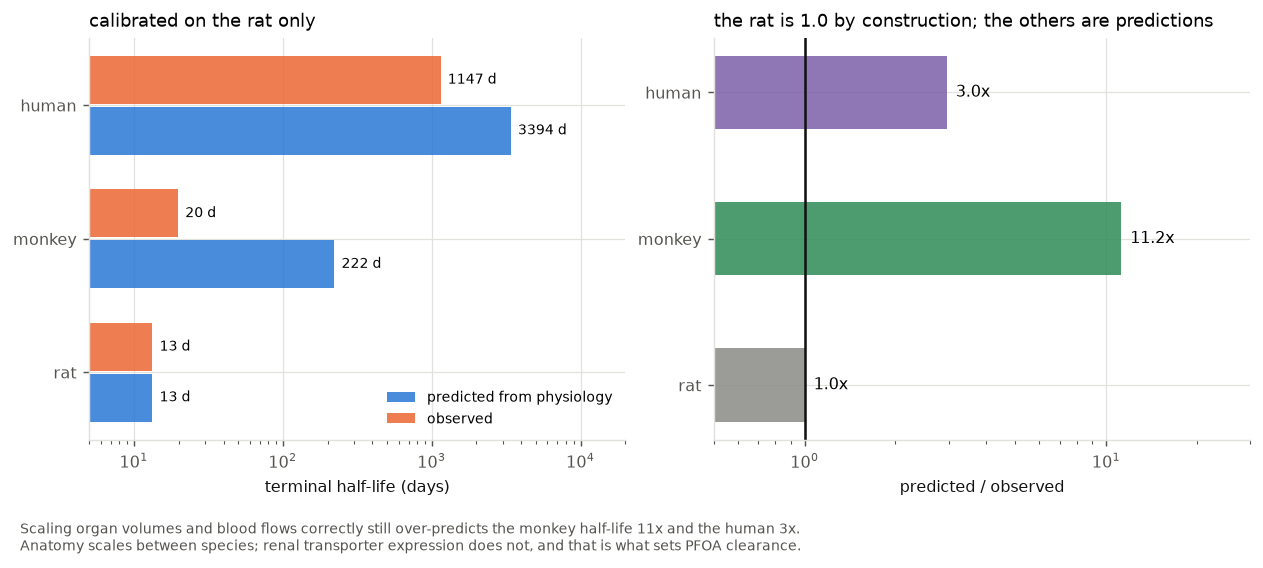

'figures/12_species_extrapolation.png'

In [9]:
fig, (a, b) = plt.subplots(1, 2, figsize=(9.6, 3.9), constrained_layout=True)
names = ["blood", "liver", "kidney", "rest"]
for j, (nm, col) in enumerate(zip(names, P.CYCLE)):
    a.plot(t, A[j] / V[nm], color=col, lw=1.6, label=nm)
a.set(xscale="log", yscale="log", xlabel="days", ylabel="concentration (mg/L)",
      xlim=(0.01, 60))
a.set_title("concentration in each organ")
a.legend(fontsize=8)

b.stackplot(t, A[0], A[1], A[2], A[3], dose_mg - total,
            colors=[P.BLUE, P.ORANGE, P.GREEN, P.PURPLE, P.GREY], alpha=0.85,
            labels=[*names, "excreted"])
b.set(xlabel="days", ylabel="amount (mg)", ylim=(0, dose_mg))
b.set_title("where the dose is")
b.legend(fontsize=7.5, loc="center right")
P.save(fig, "12_pbpk_organs.png",
       "Left: partitioning means the organs sit at different "
       "concentrations, set by P. Right: mass balance closes exactly,\n"
       "which is the check that catches a missing term faster than any "
       "fit diagnostic.")

fig, (ax, bx) = plt.subplots(1, 2, figsize=(9.6, 3.8), constrained_layout=True)

# left: predicted against observed, which is the whole claim
species = ["rat", "monkey", "human"]
y = np.arange(len(species))
ax.barh(y - 0.19, [out[n]["hl"] for n in species], height=0.36,
        color=P.BLUE, alpha=0.85, label="predicted from physiology")
ax.barh(y + 0.19, [OBSERVED_HALFLIFE_D[n] for n in species], height=0.36,
        color=P.ORANGE, alpha=0.85, label="observed")
for i, n in enumerate(species):
    ax.annotate(f"{out[n]['hl']:.0f} d", (out[n]["hl"], i - 0.19),
                xytext=(4, 0), textcoords="offset points", va="center", fontsize=8)
    ax.annotate(f"{OBSERVED_HALFLIFE_D[n]:.0f} d",
                (OBSERVED_HALFLIFE_D[n], i + 0.19), xytext=(4, 0),
                textcoords="offset points", va="center", fontsize=8)
ax.set_yticks(y, species)
ax.set(xscale="log", xlabel="terminal half-life (days)", xlim=(5, 2e4))
ax.set_title("calibrated on the rat only")
ax.legend(fontsize=8, loc="lower right")

# right: the same thing as a ratio, which makes the failure unmissable
ratios = [out[n]["hl"] / OBSERVED_HALFLIFE_D[n] for n in species]
bx.barh(y, ratios, height=0.5,
        color=[P.GREY, P.GREEN, P.PURPLE], alpha=0.85)
for i, r in enumerate(ratios):
    bx.annotate(f"{r:.1f}x", (r, i), xytext=(5, 0),
                textcoords="offset points", va="center", fontsize=9)
bx.axvline(1, color=P.INK, lw=1.4)
bx.set_yticks(y, species)
bx.set(xscale="log", xlabel="predicted / observed", xlim=(0.5, 30))
bx.set_title("the rat is 1.0 by construction; the others are predictions")
P.save(fig, "12_species_extrapolation.png",
       "Scaling organ volumes and blood flows correctly still "
       "over-predicts the monkey half-life 11x and the human 3x.\n"
       "Anatomy scales between species; renal transporter expression "
       "does not, and that is what sets PFOA clearance.")

### Questions

1. Every organ's equation has the form Q*(C_arterial - C_organ/P). What does it mean physically when that bracket is zero, and what is happening to the organ's concentration at that moment?
1. Why is elimination written as CLint * (A_kidney/V_kidney/P_kidney) rather than CLint * C_blood? What can the first form represent that the second cannot?
1. Check 2 sets every P to 1 and recovers the one-compartment model. Which physiological parameters dropped out of the answer when you did that, and why does that tell you the test is a real test?
1. Vss came out as sum(V_i * P_i). Derive that from the steady-state condition in question 1.
1. Section D gets the direction right and the magnitude wrong. If you were allowed to fit exactly ONE parameter per species to fix it, which would you choose, and what would you then NOT be allowed to claim about the model?

### Exercises

1. Add a gut compartment and an oral dose, so the model can be compared against the gavage data in PFOA_Male_rat.csv. You will need first-pass extraction through the liver -- which is the mechanism behind bioavailability F from lesson 05, now explicit instead of fitted.
1. Make CLint saturable: CLint * C/(Km + C), as in lesson 08 section C. Simulate 0.1 and 100 mg/kg and see whether the dose-dependence matches the +0.11 slope measured in ../pfas_dose.
1. Fit P_rest and CLint to the real monkey data in PFOA_Male_primate.csv, holding all physiology fixed. Compare the fitted CLint to the value this file assumes.
1. Model the sex difference from lesson 10 by changing CLint alone. What multiplier reproduces the 28x clearance ratio, and is that a plausible difference in transporter expression?
1. Swap in human physiology (70 kg, liver 2.6% of BW, kidney 0.44%, blood 7.9%; flows 22.7% and 17.5% of cardiac output) and see what half-life the model predicts before you touch CLint.